# ECLIPSE — Part III: Clustering and Prioritization

This notebook takes the two output CSVs from Part II directly as input.
No Atlas files needed — all filtering and PA proportion calculation
was already done in Part II.

### Workflow
```
mapped_p_aer_dataset_pseudomonas_specific_dark_components.csv
mapped_p_aer_dataset_eskape_enriched_dark_components.csv
          ↓
1. Length filter >= 300 aa on both tracks
          ↓
2. Export FASTA per track
          ↓
3. MMseqs2 easy-cluster on both tracks
          ↓
4. Select one representative per cluster
          ↓
5. DPPS scoring (includes cluster size as scoring axis)
          ↓
6. Ranked output tables + figures
```

### Input files (outputs from Part II)
| File | Description |
|------|-------------|
| `mapped_p_aer_dataset_pseudomonas_specific_dark_components.csv` | Pseudomonas-specific track |
| `mapped_p_aer_dataset_eskape_enriched_dark_components.csv` | ESKAPE-enriched track |

### DPPS formula
| Sub-score | Pseudomonas-specific | ESKAPE-enriched |
|-----------|---------------------|------------------|
| S1 Darkness (flat 1.0) | 0.15 | 0.15 |
| S2 PA proportion (from Atlas, Part II) | 0.40 | 0.25 |
| S3 Taxonomic specificity | 0.25 | 0.20 |
| S4 PA strain coverage: unique strains carrying component / 635 (from queryIDs) | 0.20 | 0.15 |
| S5 ESKAPE enrichment | — | 0.25 |

**Tiers:** I (DPPS >= 0.75) · II (0.50-0.75) · III (0.25-0.50) · IV (< 0.25)

---
## 0. Imports and configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import subprocess
import math
import os
import warnings
warnings.filterwarnings('ignore')

# ── Input files (Part II outputs) ────────────────────────────────────────────
PS_CSV = './mapped_p_aer_dataset_pseudomonas_specific_dark_components.csv'
ES_CSV = './mapped_p_aer_dataset_eskape_enriched_dark_components.csv'

# ── Filtering ────────────────────────────────────────────────────────────────
MIN_SEQ_LEN  = 300
N_PA_STRAINS = 635  # total PA strains in your dataset

# ── MMseqs2 clustering parameters ────────────────────────────────────────────
MMSEQS_MIN_SEQ_ID = 0.3
MMSEQS_COVERAGE   = 0.8
MMSEQS_TMP        = './tmp_mmseqs'

# ── DPPS weights — Pseudomonas-specific track ─────────────────────────────────
WEIGHTS_PS = {
    'S1_darkness':          0.15,
    'S2_pa_proportion':     0.40,
    'S3_specificity':       0.25,
    'S4_pa_strain_coverage':0.20,
}
assert abs(sum(WEIGHTS_PS.values()) - 1.0) < 1e-9, 'WEIGHTS_PS must sum to 1.0'

# ── DPPS weights — ESKAPE-enriched track ──────────────────────────────────────
WEIGHTS_ES = {
    'S1_darkness':           0.15,
    'S2_pa_proportion':      0.25,
    'S3_specificity':        0.20,
    'S4_pa_strain_coverage': 0.15,
    'S5_eskape_enrich':      0.25,
}
assert abs(sum(WEIGHTS_ES.values()) - 1.0) < 1e-9, 'WEIGHTS_ES must sum to 1.0'

# ── Tier boundaries ───────────────────────────────────────────────────────────
TIER_BINS   = [0, 0.25, 0.50, 0.75, 1.01]
TIER_LABELS = ['IV', 'III', 'II', 'I']
TIER_COLORS = {'I': '#7B2D8B', 'II': '#D85A30', 'III': '#1D9E75', 'IV': '#888780'}

os.makedirs(MMSEQS_TMP, exist_ok=True)
print('Configuration loaded.')
print(f'  Pseudomonas-specific input: {PS_CSV}')
print(f'  ESKAPE-enriched input:      {ES_CSV}')
print(f'  Min sequence length:        {MIN_SEQ_LEN} aa')
print(f'  PA strains total:           {N_PA_STRAINS}')
print(f'  MMseqs2: min-seq-id={MMSEQS_MIN_SEQ_ID}, coverage={MMSEQS_COVERAGE}')

Configuration loaded.
  Pseudomonas-specific input: ./mapped_p_aer_dataset_pseudomonas_specific_dark_components.csv
  ESKAPE-enriched input:      ./mapped_p_aer_dataset_eskape_enriched_dark_components.csv
  Min sequence length:        300 aa
  PA strains total:           635
  MMseqs2: min-seq-id=0.3, coverage=0.8


---
## 1. Load Part II outputs

In [2]:
df_ps = pd.read_csv(PS_CSV)
df_es = pd.read_csv(ES_CSV)

print(f'Pseudomonas-specific: {len(df_ps):,} proteins, '
      f'{df_ps["componentID"].nunique():,} components')
print(f'ESKAPE-enriched:      {len(df_es):,} proteins, '
      f'{df_es["componentID"].nunique():,} components')
print(f'\nColumns: {list(df_ps.columns)}')

Pseudomonas-specific: 17,609 proteins, 102 components
ESKAPE-enriched:      35,073 proteins, 196 components

Columns: ['queryID', 'SEQ', 'targetID', 'fident', 'alnlen', 'mismatch', 'gapopen', 'qstart', 'qend', 'tstart', 'tend', 'eVal', 'bits', 'communityID', 'brightness', 'componentID', 'component_brightness', 'ESKAPE_relative_evenness', 'ESKAPE_genus_evenness', 'ESKAPE_proportion', 'p_aeruginosa_proportion', 'track']


---
## 2. Length filter >= 300 aa on both tracks

Pseudomonas-specific:
  Before: 17,609 proteins, 102 components
  Dropped: 81 components (median seq len < 300 aa)
  Dropped: 13,367 proteins from those components
  Retained: 4,242 proteins, 21 components
  Dropped component median lengths:
 componentID  median_seq_len
      107877            46.0
       51064            65.0
      168893            65.0
      158399            65.5
       79969            67.0
       33738            71.0
      129813            75.0
      118183            80.0
      118093            82.0
       61895            84.0
       33561            85.0
      184475            86.0
      194242            88.0
       92485            89.0
       23464            91.0
      130808            92.0
      118432            92.0
       67756            99.0
      122823            99.0
      158400           100.0
      155614           100.0
       91708           102.0
      112954           107.0
      123371           107.0
      114039           112.0
    

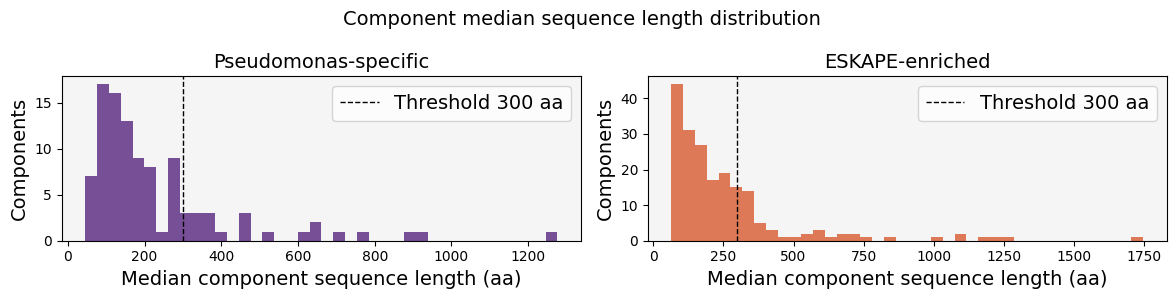

Saved: seq_len_both_tracks.pdf


In [18]:
def apply_length_filter(df_in, track_name, min_len=MIN_SEQ_LEN):
    """
    Filter by MEDIAN component sequence length, not individual protein length.
    This correctly handles components like 103202 where 623/626 proteins are
    265 aa but 3 outlier proteins are 304-340 aa — the component should be
    excluded based on its representative (median) length, not the outliers.
    """
    df_out = df_in.copy()
    df_out['seq_len'] = df_out['SEQ'].str.len()

    # Compute median sequence length per component
    comp_median_len = (
        df_out.groupby('componentID')['seq_len']
        .median()
        .reset_index(name='median_seq_len')
    )

    # Identify components where median length >= threshold
    valid_comps = comp_median_len.loc[
        comp_median_len['median_seq_len'] >= min_len, 'componentID'
    ].tolist()

    n_comps_before = df_out['componentID'].nunique()
    n_prots_before = len(df_out)

    # Keep ALL proteins from valid components
    df_out = df_out[df_out['componentID'].isin(valid_comps)].copy()

    n_comps_dropped = n_comps_before - df_out['componentID'].nunique()
    n_prots_dropped = n_prots_before - len(df_out)

    print(f'{track_name}:')
    print(f'  Before: {n_prots_before:,} proteins, {n_comps_before:,} components')
    print(f'  Dropped: {n_comps_dropped:,} components (median seq len < {min_len} aa)')
    print(f'  Dropped: {n_prots_dropped:,} proteins from those components')
    print(f'  Retained: {len(df_out):,} proteins, '
          f'{df_out["componentID"].nunique():,} components')

    # Show dropped components and their median lengths for transparency
    dropped = comp_median_len[~comp_median_len['componentID'].isin(valid_comps)]
    if len(dropped) > 0:
        print(f'  Dropped component median lengths:')
        print(dropped.sort_values('median_seq_len').to_string(index=False))

    return df_out

df_ps_filt = apply_length_filter(df_ps, 'Pseudomonas-specific')
print()
df_es_filt = apply_length_filter(df_es, 'ESKAPE-enriched')

# Length distribution plots — show median seq len per component
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
for ax, df_in, title, color in zip(
        axes,
        [df_ps, df_es],
        ['Pseudomonas-specific', 'ESKAPE-enriched'],
        ['#57257F', '#D85A30']):
    df_in = df_in.copy()
    df_in['seq_len'] = df_in['SEQ'].str.len()
    median_lens = df_in.groupby('componentID')['seq_len'].median()
    ax.hist(median_lens, bins=40, color=color, alpha=0.8, edgecolor='none')
    ax.axvline(MIN_SEQ_LEN, color='black', linewidth=1, linestyle='--',
               label=f'Threshold {MIN_SEQ_LEN} aa')
    ax.set_xlabel('Median component sequence length (aa)', fontsize=14)
    ax.set_ylabel('Components', fontsize=14)
    ax.set_title(title, fontsize=14)
    ax.legend(fontsize=14)
    ax.set_facecolor('#F5F5F5')
fig.suptitle('Component median sequence length distribution', fontsize=14)
fig.tight_layout()
plt.savefig('./seq_len_both_tracks.pdf', bbox_inches='tight', dpi=300)
plt.show()
print('Saved: seq_len_both_tracks.pdf')


---
## 3. Export FASTA files

In [4]:
def write_fasta(df_in, fasta_path):
    df_unique = df_in.drop_duplicates(subset='queryID')
    with open(fasta_path, 'w') as fh:
        for _, row in df_unique.iterrows():
            fh.write(f'>{row["queryID"]}\n{row["SEQ"]}\n')
    print(f'Written {len(df_unique):,} sequences -> {fasta_path}')

write_fasta(df_ps_filt, './track_ps_pseudomonas_specific.fasta')
write_fasta(df_es_filt, './track_es_eskape_enriched.fasta')

Written 4,242 sequences -> ./track_ps_pseudomonas_specific.fasta
Written 12,307 sequences -> ./track_es_eskape_enriched.fasta


---
## 4. MMseqs2 easy-cluster

Groups similar sequences into clusters — replacing the manual CLANS step.
Adjust `MMSEQS_MIN_SEQ_ID` and `MMSEQS_COVERAGE` in Section 0 to match
the parameters you used manually.

In [5]:
def run_mmseqs_cluster(fasta_in, prefix, tmp_dir, min_seq_id, coverage):
    cluster_tsv = f'{prefix}_cluster.tsv'
    cmd = [
        'mmseqs', 'easy-cluster',
        fasta_in, prefix, tmp_dir,
        '--min-seq-id', str(min_seq_id),
        '-c',           str(coverage),
        '--cov-mode',   '0',
        '-v',           '1'
    ]
    print(f'Running: {" ".join(cmd)}')
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print('MMseqs2 stderr:')
        print(result.stderr[-1000:])
        return None
    print(result.stdout[-500:] if len(result.stdout) > 500 else result.stdout)
    return cluster_tsv

tsv_ps = run_mmseqs_cluster(
    './track_ps_pseudomonas_specific.fasta',
    './cluster_ps', MMSEQS_TMP, MMSEQS_MIN_SEQ_ID, MMSEQS_COVERAGE
)
print()
tsv_es = run_mmseqs_cluster(
    './track_es_eskape_enriched.fasta',
    './cluster_es', MMSEQS_TMP, MMSEQS_MIN_SEQ_ID, MMSEQS_COVERAGE
)

Running: mmseqs easy-cluster ./track_ps_pseudomonas_specific.fasta ./cluster_ps ./tmp_mmseqs --min-seq-id 0.3 -c 0.8 --cov-mode 0 -v 1


Running: mmseqs easy-cluster ./track_es_eskape_enriched.fasta ./cluster_es ./tmp_mmseqs --min-seq-id 0.3 -c 0.8 --cov-mode 0 -v 1



---
## 5. Select one representative per cluster

MMseqs2 picks one representative per cluster automatically.
Cluster size is recorded — a representative standing for a large cluster
means that sequence pattern is widely conserved across your dataset.

In [6]:
def parse_clusters(cluster_tsv, df_filtered, track_name):
    """
    Parse MMseqs2 cluster TSV (col0=representative, col1=member).
    Returns dataframe of representative proteins with cluster_size column.
    """
    clusters = pd.read_csv(cluster_tsv, sep='\t', header=None,
                           names=['representative', 'member'])

    # Count members per representative = cluster size
    cluster_sizes = (
        clusters.groupby('representative')
        .size()
        .reset_index(name='cluster_size')
    )

    # Select representative rows from filtered protein table
    reps = df_filtered.loc[
        df_filtered['queryID'].isin(cluster_sizes['representative'])
    ].drop_duplicates(subset='queryID').copy()

    reps = reps.merge(
        cluster_sizes, left_on='queryID', right_on='representative', how='left'
    )
    reps['cluster_size'] = reps['cluster_size'].fillna(1).astype(int)

    print(f'{track_name}:')
    print(f'  Proteins after length filter: {len(df_filtered):,}')
    print(f'  Clusters formed:              {len(cluster_sizes):,}')
    print(f'  Representatives selected:     {len(reps):,}')
    print(f'  Redundant sequences removed:  {len(df_filtered) - len(reps):,}')
    print(f'  Cluster size — mean: {reps["cluster_size"].mean():.1f}, '
          f'max: {reps["cluster_size"].max()}')
    return reps

print('Pseudomonas-specific:')
reps_ps = parse_clusters(tsv_ps, df_ps_filt, 'Pseudomonas-specific')
print()
print('ESKAPE-enriched:')
reps_es = parse_clusters(tsv_es, df_es_filt, 'ESKAPE-enriched')

Pseudomonas-specific:
Pseudomonas-specific:
  Proteins after length filter: 4,242
  Clusters formed:              29
  Representatives selected:     29
  Redundant sequences removed:  4,213
  Cluster size — mean: 146.3, max: 1253

ESKAPE-enriched:
ESKAPE-enriched:
  Proteins after length filter: 12,307
  Clusters formed:              92
  Representatives selected:     92
  Redundant sequences removed:  12,215
  Cluster size — mean: 133.8, max: 1931


---
## 6. Build component-level tables

Scoring happens at component level. Cluster size is aggregated per component
as the maximum cluster size among all representatives in that component —
the largest cluster within a component is the most informative signal.

In [7]:
COMP_COLS = ['componentID', 'component_brightness', 'ESKAPE_proportion',
             'ESKAPE_genus_evenness', 'ESKAPE_relative_evenness',
             'p_aeruginosa_proportion']

def build_component_table(df_filtered, track_name):
    # One row per component
    comp = df_filtered[COMP_COLS].drop_duplicates(subset='componentID').copy()

    # PA strain coverage: count unique strains per component directly from queryIDs
    # queryID format: STRAIN_PROTEINID (e.g. PAO1_PA0001) → strain = PAO1
    # Threshold-independent — directly measures conservation across your 635 strains
    df_copy = df_filtered.copy()
    df_copy['strain'] = df_copy['queryID'].str.split('_').str[0]
    strain_counts = (
        df_copy.groupby('componentID')['strain']
        .nunique()
        .reset_index(name='PA_strain_count')
    )
    strain_counts['PA_strain_fraction'] = (
        strain_counts['PA_strain_count'] / N_PA_STRAINS
    ).clip(0, 1)

    comp = comp.merge(strain_counts, on='componentID', how='left')
    comp['PA_strain_count']    = comp['PA_strain_count'].fillna(0).astype(int)
    comp['PA_strain_fraction'] = comp['PA_strain_fraction'].fillna(0.0)

    print(f'{track_name}: {len(comp):,} components')
    print(f'  PA strain count   — mean: {comp["PA_strain_count"].mean():.1f}, '
          f'max: {comp["PA_strain_count"].max()}')
    print(f'  PA strain fraction — mean: {comp["PA_strain_fraction"].mean():.3f}, '
          f'max: {comp["PA_strain_fraction"].max():.3f}')
    return comp.reset_index(drop=True)

comp_ps = build_component_table(df_ps_filt, 'Pseudomonas-specific')
comp_es = build_component_table(df_es_filt, 'ESKAPE-enriched')


Pseudomonas-specific: 21 components
  PA strain count   — mean: 156.1, max: 636
  PA strain fraction — mean: 0.246, max: 1.000
ESKAPE-enriched: 53 components
  PA strain count   — mean: 204.2, max: 636
  PA strain fraction — mean: 0.322, max: 1.000


---
## 7. DPPS scoring

**S1** — darkness: flat 1.0 for all (component_brightness == 0)  
**S2** — PA proportion: directly from Part II Atlas calculation  
**S3** — taxonomic specificity: `1 - ESKAPE_relative_evenness`  
**S4** — PA strain coverage: `unique PA strains carrying component / 635` (from queryIDs)  
**S5** — ESKAPE enrichment (Track B only): `ESKAPE_proportion x (1 - ESKAPE_genus_evenness)`

In [8]:
def compute_dpps(comp_df, weights, track_name):
    comp = comp_df.copy()

    # S1 — darkness (flat 1.0 since all component_brightness == 0)
    comp['S1_darkness'] = (1.0 - comp['component_brightness'] / 100.0).clip(0, 1)

    # S2 — real PA proportion from Atlas (computed in Part II)
    comp['S2_pa_proportion'] = comp['p_aeruginosa_proportion'].clip(0, 1)

    # S3 — taxonomic specificity: exclusive to AMR clade globally
    comp['S3_specificity'] = (1.0 - comp['ESKAPE_relative_evenness']).clip(0, 1)

    # S4 — PA strain coverage: fraction of 635 PA strains carrying this component
    # Computed directly from queryIDs — threshold-independent, biologically meaningful
    comp['S4_pa_strain_coverage'] = comp['PA_strain_fraction'].clip(0, 1)

    # S5 — ESKAPE enrichment (ESKAPE-enriched track only)
    if 'S5_eskape_enrich' in weights:
        comp['S5_eskape_enrich'] = (
            comp['ESKAPE_proportion'] * (1.0 - comp['ESKAPE_genus_evenness'])
        ).clip(0, 1)

    # Composite DPPS
    comp['DPPS'] = sum(
        weights[col] * comp[col] for col in weights if col in comp.columns
    ).clip(0, 1)

    # Tier assignment
    comp['tier'] = pd.cut(
        comp['DPPS'], bins=TIER_BINS, labels=TIER_LABELS, right=False
    ).astype(str)

    comp['track'] = track_name
    comp.sort_values('DPPS', ascending=False, inplace=True)
    comp.reset_index(drop=True, inplace=True)

    print(f'{track_name} — DPPS summary:')
    print(comp['DPPS'].describe().round(3))
    print('Tier counts:')
    print(comp['tier'].value_counts().sort_index())
    return comp

print('=== Pseudomonas-specific ===')
comp_ps_scored = compute_dpps(comp_ps, WEIGHTS_PS, 'Pseudomonas-specific')
print()
print('=== ESKAPE-enriched ===')
comp_es_scored = compute_dpps(comp_es, WEIGHTS_ES, 'ESKAPE-enriched')


=== Pseudomonas-specific ===
Pseudomonas-specific — DPPS summary:
count    21.000
mean      0.478
std       0.107
min       0.400
25%       0.400
50%       0.409
75%       0.534
max       0.760
Name: DPPS, dtype: float64
Tier counts:
tier
I       1
II      6
III    14
Name: count, dtype: int64

=== ESKAPE-enriched ===
ESKAPE-enriched — DPPS summary:
count    53.000
mean      0.469
std       0.172
min       0.206
25%       0.287
50%       0.452
75%       0.615
max       0.908
Name: DPPS, dtype: float64
Tier counts:
tier
I       3
II     20
III    28
IV      2
Name: count, dtype: int64


In [9]:
# Propagate component scores back to representative proteins
def merge_scores_to_reps(reps_df, comp_scored):
    score_cols = ['componentID', 'DPPS', 'tier', 'track',
                  'S1_darkness', 'S2_pa_proportion', 'S3_specificity',
                  'S4_pa_strain_coverage', 'PA_strain_count', 'PA_strain_fraction',
                  'p_aeruginosa_proportion']
    if 'S5_eskape_enrich' in comp_scored.columns:
        score_cols.append('S5_eskape_enrich')
    scored = reps_df.merge(comp_scored[score_cols], on='componentID', how='left')
    scored.sort_values('DPPS', ascending=False, inplace=True)
    scored.reset_index(drop=True, inplace=True)
    return scored

reps_ps_scored = merge_scores_to_reps(reps_ps, comp_ps_scored)
reps_es_scored = merge_scores_to_reps(reps_es, comp_es_scored)

print(f'Pseudomonas-specific representatives scored: {len(reps_ps_scored):,}')
print(f'ESKAPE-enriched representatives scored:      {len(reps_es_scored):,}')

Pseudomonas-specific representatives scored: 29
ESKAPE-enriched representatives scored:      92


---
## 8. Save outputs

In [10]:
comp_ps_scored.to_csv('./dpps_components_pseudomonas_specific.csv', index=False)
comp_es_scored.to_csv('./dpps_components_eskape_enriched.csv', index=False)
reps_ps_scored.to_csv('./dpps_representatives_pseudomonas_specific.csv', index=False)
reps_es_scored.to_csv('./dpps_representatives_eskape_enriched.csv', index=False)

tier1_ps = reps_ps_scored[reps_ps_scored['tier'] == 'I']
tier1_es = reps_es_scored[reps_es_scored['tier'] == 'I']
tier1_ps.to_csv('./dpps_tier1_pseudomonas_specific.csv', index=False)
tier1_es.to_csv('./dpps_tier1_eskape_enriched.csv', index=False)

combined = pd.concat([reps_ps_scored, reps_es_scored], axis=0)
combined.sort_values('DPPS', ascending=False, inplace=True)
combined.to_csv('./dpps_all_representatives_combined.csv', index=False)

print('Output files saved:')
for f in [
    'dpps_components_pseudomonas_specific.csv',
    'dpps_components_eskape_enriched.csv',
    'dpps_representatives_pseudomonas_specific.csv',
    'dpps_representatives_eskape_enriched.csv',
    'dpps_tier1_pseudomonas_specific.csv',
    'dpps_tier1_eskape_enriched.csv',
    'dpps_all_representatives_combined.csv',
]:
    exists = '\u2713' if os.path.exists(f'./{f}') else '\u25cb'
    print(f'  {exists}  {f}')

Output files saved:
  ✓  dpps_components_pseudomonas_specific.csv
  ✓  dpps_components_eskape_enriched.csv
  ✓  dpps_representatives_pseudomonas_specific.csv
  ✓  dpps_representatives_eskape_enriched.csv
  ✓  dpps_tier1_pseudomonas_specific.csv
  ✓  dpps_tier1_eskape_enriched.csv
  ✓  dpps_all_representatives_combined.csv


---
## 9. Visualisations
### 9.1 DPPS distribution — both tracks

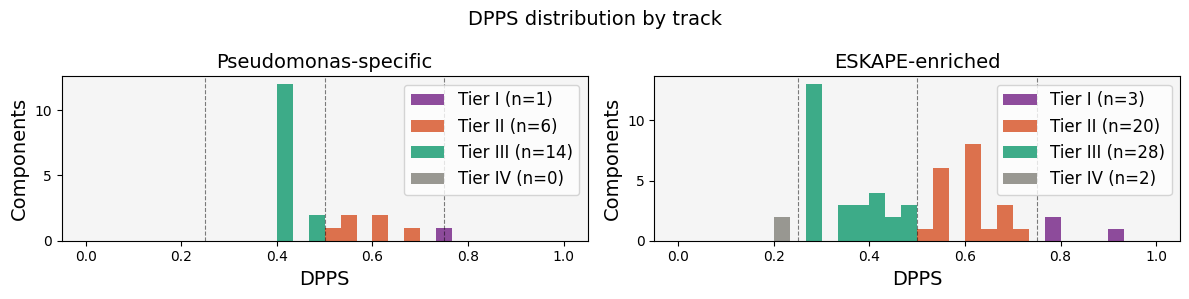

Saved: dpps_distribution_both_tracks.pdf


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
for ax, comp_scored, title in zip(
        axes,
        [comp_ps_scored, comp_es_scored],
        ['Pseudomonas-specific', 'ESKAPE-enriched']):
    bins = np.linspace(0, 1, 31)
    for tier, color in TIER_COLORS.items():
        subset = comp_scored.loc[comp_scored['tier'] == tier, 'DPPS']
        ax.hist(subset, bins=bins, color=color, alpha=0.85,
                label=f'Tier {tier} (n={len(subset)})')
    for b in TIER_BINS[1:-1]:
        ax.axvline(b, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_xlabel('DPPS', fontsize=14)
    ax.set_ylabel('Components', fontsize=14)
    ax.set_title(title, fontsize=14)
    ax.legend(fontsize=12)
    ax.set_facecolor('#F5F5F5')
fig.suptitle('DPPS distribution by track', fontsize=14)
fig.tight_layout()
plt.savefig('./dpps_distribution_both_tracks.pdf', bbox_inches='tight', dpi=300)
plt.show()
print('Saved: dpps_distribution_both_tracks.pdf')

### 9.2 PA proportion vs DPPS coloured by cluster size

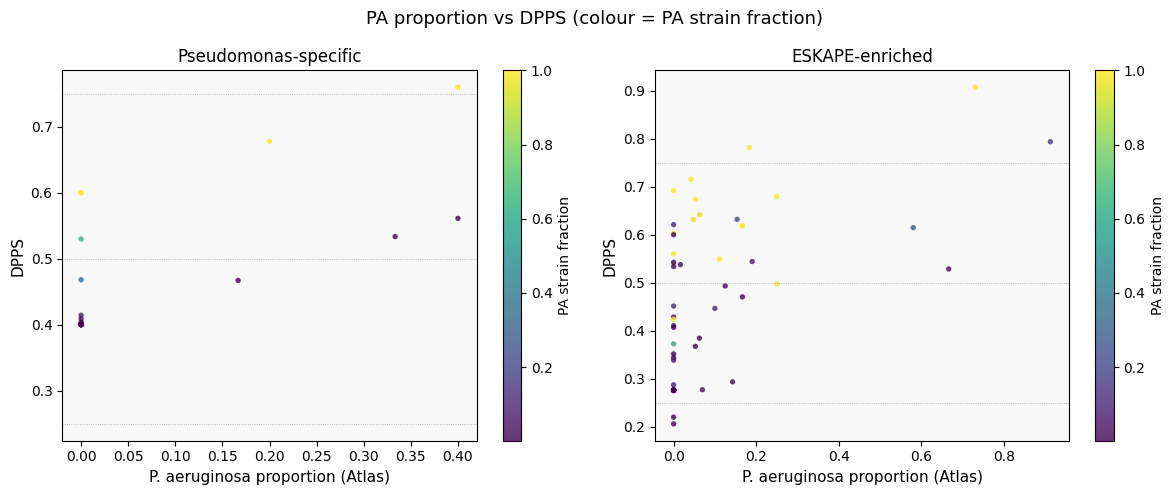

Saved: dpps_pa_proportion_scatter.pdf


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, comp_scored, title in zip(
        axes,
        [comp_ps_scored, comp_es_scored],
        ['Pseudomonas-specific', 'ESKAPE-enriched']):
    scatter = ax.scatter(
        comp_scored['p_aeruginosa_proportion'],
        comp_scored['DPPS'],
        c=comp_scored['PA_strain_fraction'],
        cmap='viridis', s=15, alpha=0.8, linewidths=0
    )
    for b in TIER_BINS[1:-1]:
        ax.axhline(b, color='gray', linewidth=0.6, linestyle=':', alpha=0.7)
    plt.colorbar(scatter, ax=ax, label='PA strain fraction')
    ax.set_xlabel('P. aeruginosa proportion (Atlas)', fontsize=11)
    ax.set_ylabel('DPPS', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.set_facecolor('#F8F8F8')
fig.suptitle('PA proportion vs DPPS (colour = PA strain fraction)', fontsize=13)
fig.tight_layout()
plt.savefig('./dpps_pa_proportion_scatter.pdf', bbox_inches='tight', dpi=300)
plt.show()
print('Saved: dpps_pa_proportion_scatter.pdf')

### 9.3 Sub-score heatmap — top 30 Tier I per track

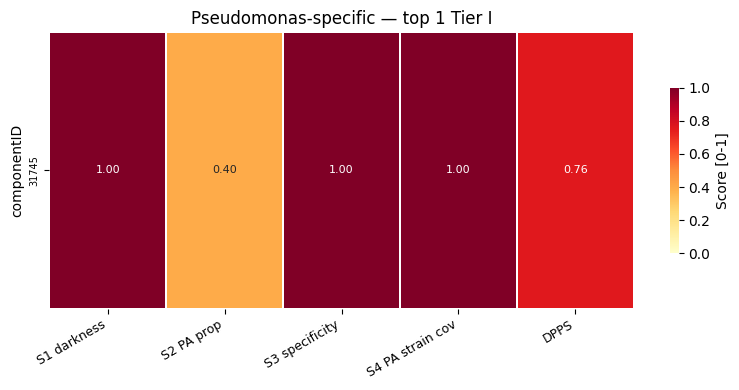

Saved: ./dpps_heatmap_pseudomonas_specific.pdf


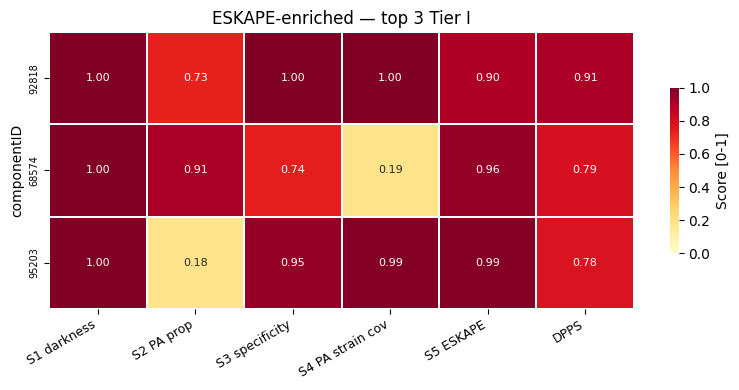

Saved: ./dpps_heatmap_eskape_enriched.pdf


In [13]:
def score_heatmap(comp_scored, score_cols, xlabels, title, fname):
    top = comp_scored[comp_scored['tier'] == 'I'].head(30)
    if len(top) == 0:
        top = comp_scored.head(30)
        print(f'No Tier I found — showing top 30 overall for {title}')
    data = top.set_index('componentID')[score_cols]
    fig, ax = plt.subplots(figsize=(8, max(4, len(top) * 0.30)))
    sns.heatmap(data, ax=ax, cmap='YlOrRd', vmin=0, vmax=1,
                annot=True, fmt='.2f', annot_kws={'size': 8},
                linewidths=0.3, linecolor='white',
                cbar_kws={'label': 'Score [0-1]', 'shrink': 0.6})
    ax.set_title(f'{title} — top {len(top)} Tier I', fontsize=12)
    ax.set_xticklabels(xlabels, rotation=30, ha='right', fontsize=9)
    ax.tick_params(axis='y', labelsize=7)
    fig.tight_layout()
    plt.savefig(fname, bbox_inches='tight', dpi=300)
    plt.show()
    print(f'Saved: {fname}')

score_heatmap(
    comp_ps_scored,
    ['S1_darkness', 'S2_pa_proportion', 'S3_specificity', 'S4_pa_strain_coverage', 'DPPS'],
    ['S1 darkness', 'S2 PA prop', 'S3 specificity', 'S4 PA strain cov', 'DPPS'],
    'Pseudomonas-specific',
    './dpps_heatmap_pseudomonas_specific.pdf'
)

score_heatmap(
    comp_es_scored,
    ['S1_darkness', 'S2_pa_proportion', 'S3_specificity', 'S4_pa_strain_coverage', 'S5_eskape_enrich', 'DPPS'],
    ['S1 darkness', 'S2 PA prop', 'S3 specificity', 'S4 PA strain cov', 'S5 ESKAPE', 'DPPS'],
    'ESKAPE-enriched',
    './dpps_heatmap_eskape_enriched.pdf'
)

### 9.4 Cluster size distribution

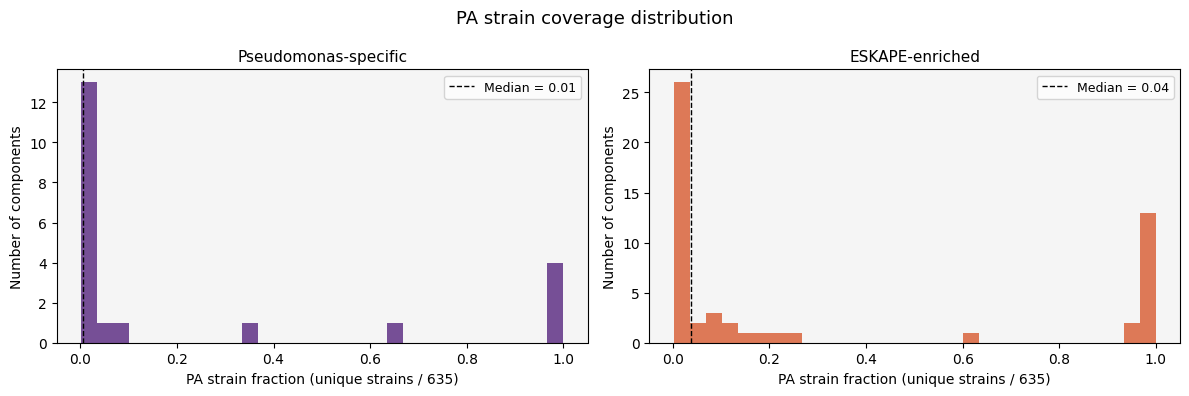

Saved: pa_strain_coverage_distribution.pdf


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, comp_scored, title, color in zip(
        axes,
        [comp_ps_scored, comp_es_scored],
        ['Pseudomonas-specific', 'ESKAPE-enriched'],
        ['#57257F', '#D85A30']):
    ax.hist(comp_scored['PA_strain_fraction'], bins=30,
            color=color, alpha=0.8, edgecolor='none')
    median_sf = comp_scored['PA_strain_fraction'].median()
    ax.axvline(median_sf, color='black', linewidth=1, linestyle='--',
               label=f'Median = {median_sf:.2f}')
    ax.set_xlabel('PA strain fraction (unique strains / 635)', fontsize=10)
    ax.set_ylabel('Number of components', fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.set_facecolor('#F5F5F5')
fig.suptitle('PA strain coverage distribution', fontsize=13)
fig.tight_layout()
plt.savefig('./pa_strain_coverage_distribution.pdf', bbox_inches='tight', dpi=300)
plt.show()
print('Saved: pa_strain_coverage_distribution.pdf')

---
## 10. Summary report

In [15]:
print('=' * 65)
print('ECLIPSE Part III — Summary')
print('=' * 65)

for track, df_raw, df_filt, comp_s, reps_s in [
    ('Pseudomonas-specific', df_ps, df_ps_filt, comp_ps_scored, reps_ps_scored),
    ('ESKAPE-enriched',      df_es, df_es_filt, comp_es_scored, reps_es_scored),
]:
    print(f'\n--- {track} ---')
    print(f'  Input from Part II:    {len(df_raw):,} proteins, '
          f'{df_raw["componentID"].nunique():,} components')
    print(f'  After length filter:   {len(df_filt):,} proteins, '
          f'{df_filt["componentID"].nunique():,} components')
    print(f'  After clustering:      {len(reps_s):,} representatives')
    for tier in ['I', 'II', 'III', 'IV']:
        n = int((comp_s['tier'] == tier).sum())
        m = comp_s.loc[comp_s['tier'] == tier, 'DPPS'].mean()
        print(f'  Tier {tier}: {n:>4,} components  mean DPPS = {m:.3f}')

print()
print('Top 5 — Pseudomonas-specific:')
print(comp_ps_scored[[
    'componentID', 'DPPS', 'tier',
    'S2_pa_proportion', 'S3_specificity',
    'S4_pa_strain_coverage', 'PA_strain_count',
    'p_aeruginosa_proportion'
]].head(5).round(3).to_string(index=False))

print()
print('Top 5 — ESKAPE-enriched:')
print(comp_es_scored[[
    'componentID', 'DPPS', 'tier',
    'S2_pa_proportion', 'S5_eskape_enrich',
    'S4_pa_strain_coverage', 'PA_strain_count',
    'p_aeruginosa_proportion'
]].head(5).round(3).to_string(index=False))

ECLIPSE Part III — Summary

--- Pseudomonas-specific ---
  Input from Part II:    17,609 proteins, 102 components
  After length filter:   4,242 proteins, 21 components
  After clustering:      29 representatives
  Tier I:    1 components  mean DPPS = 0.760
  Tier II:    6 components  mean DPPS = 0.584
  Tier III:   14 components  mean DPPS = 0.412
  Tier IV:    0 components  mean DPPS = nan

--- ESKAPE-enriched ---
  Input from Part II:    35,073 proteins, 196 components
  After length filter:   12,307 proteins, 53 components
  After clustering:      92 representatives
  Tier I:    3 components  mean DPPS = 0.828
  Tier II:   20 components  mean DPPS = 0.607
  Tier III:   28 components  mean DPPS = 0.350
  Tier IV:    2 components  mean DPPS = 0.213

Top 5 — Pseudomonas-specific:
 componentID  DPPS tier  S2_pa_proportion  S3_specificity  S4_pa_strain_coverage  PA_strain_count  p_aeruginosa_proportion
       31745 0.760    I               0.4             1.0                  1.000     

---
## 11. Weight sensitivity analysis — both tracks

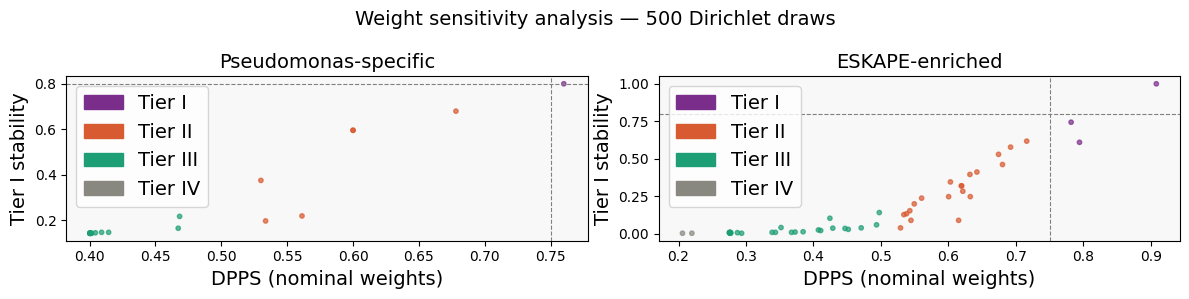

Saved: dpps_sensitivity_both_tracks.pdf


In [25]:
def sensitivity_analysis(comp_scored, weight_keys, n_boot=500):
    np.random.seed(42)
    n_scores = len(weight_keys)
    score_matrix = comp_scored[weight_keys].values
    tier1_freq = np.zeros(len(comp_scored))
    for _ in range(n_boot):
        w = np.random.dirichlet(np.ones(n_scores))
        dpps_boot = np.clip(score_matrix @ w, 0, 1)
        tier1_freq += (dpps_boot >= 0.75).astype(float)
    comp_out = comp_scored.copy()
    comp_out['tier1_stability'] = tier1_freq / n_boot
    return comp_out

comp_ps_scored = sensitivity_analysis(comp_ps_scored, list(WEIGHTS_PS.keys()))
comp_es_scored = sensitivity_analysis(comp_es_scored, list(WEIGHTS_ES.keys()))

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
for ax, comp_scored, title in zip(
        axes,
        [comp_ps_scored, comp_es_scored],
        ['Pseudomonas-specific', 'ESKAPE-enriched']):
    ax.scatter(comp_scored['DPPS'], comp_scored['tier1_stability'],
               c=[TIER_COLORS.get(t, 'gray') for t in comp_scored['tier']],
               s=10, alpha=0.7)
    ax.axhline(0.8, linestyle='--', color='gray', linewidth=0.8, label='80% stability')
    ax.axvline(0.75, linestyle='--', color='gray', linewidth=0.8)
    ax.set_xlabel('DPPS (nominal weights)', fontsize=14)
    ax.set_ylabel('Tier I stability', fontsize=14)
    ax.set_title(title, fontsize=14)
    patches = [mpatches.Patch(color=c, label=f'Tier {t}') for t, c in TIER_COLORS.items()]
    ax.legend(handles=patches, fontsize=14)
    ax.set_facecolor('#F8F8F8')
fig.suptitle('Weight sensitivity analysis — 500 Dirichlet draws', fontsize=14)
fig.tight_layout()
plt.savefig('./dpps_sensitivity_both_tracks.pdf', bbox_inches='tight', dpi=300)
plt.show()
print('Saved: dpps_sensitivity_both_tracks.pdf')